In [25]:
import pandas as pd 
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [4]:
def merge_dfs(dfs:list):
    for i in range(len(dfs)):
        if i==0:
            df=dfs[i]
        else:
            df = pd.merge(df, dfs[i], left_index=True, right_index=True)
    return df

def clean_process(df):
    df=df.where(df!=0,np.nan)                               # - Replace 0 with NaNs
    df=df.dropna()                                          # - Drop NaNs (preliminarily)
    df=df.resample('D', kind='timestamp', ).asfreq()        # - Make sure time axis is even
    df=df.interpolate('linear')                             # - Fill resulting NaNs with linear interpolation
    return df

# Load, Process, Align Dates

In [ ]:
folder=r'/Users/igorbykov/Desktop/Thesis/data'

# Get TTF data
name=r'commodities_data_v0.xlsx'
brent = pd.read_excel(
    os.path.join(folder,name),
    usecols=[0,1],
    index_col=0
    )
brent.index = pd.to_datetime(brent.index) # - TTF Nat Gas Spot; USD (assumed)
brent = clean_process(brent)

# Utility debt yield index data (10Y)
name=r'utilities_debt.xlsx'
util_yield_10y=pd.read_excel(
    os.path.join(folder,name),
    usecols=[0,3],
    index_col=0
    )
util_yield_10y.index = pd.to_datetime(util_yield_10y.index)     # - Ensure datatime indexation
util_yield_10y = clean_process(util_yield_10y)

# Get EUR curve data (10Y)
name=r'euro_curve.xlsx'
govt_yield_10y=pd.read_excel(
    os.path.join(folder,name),
    usecols=[0,2],
    index_col=0
    )
govt_yield_10y.index = pd.to_datetime(govt_yield_10y.index)     # - Ensure datatime indexation
govt_yield_10y = clean_process(govt_yield_10y)

# df = merge_dfs([brent, util_yield_10y, govt_yield_10y])

/var/folders/4_/ym5ph8gd12lfqnhrxz6p53rw0000gn/T/ipykernel_10472/4113266116.py:12: FutureWarning: The 'kind' keyword in DataFrame.resample is deprecated and will be removed in a future version. Explicitly cast the index to the desired type instead
  df=df.resample('D', kind='timestamp', ).asfreq()        # - Make sure time axis is even
/var/folders/4_/ym5ph8gd12lfqnhrxz6p53rw0000gn/T/ipykernel_10472/4113266116.py:12: FutureWarning: The 'kind' keyword in DataFrame.resample is deprecated and will be removed in a future version. Explicitly cast the index to the desired type instead
  df=df.resample('D', kind='timestamp', ).asfreq()        # - Make sure time axis is even
/var/folders/4_/ym5ph8gd12lfqnhrxz6p53rw0000gn/T/ipykernel_10472/4113266116.py:12: FutureWarning: The 'kind' keyword in DataFrame.resample is deprecated and will be removed in a future version. Explicitly cast the index to the desired type instead
  df=df.resample('D', kind='timestamp', ).asfreq()        # - Make sure time

# Duration Assumptions, Convert to Log-Returns, Combine

/Users/igorbykov/opt/anaconda3/envs/quant/lib/python3.14/site-packages/pandas/core/internals/blocks.py:395: RuntimeWarning: invalid value encountered in log1p
  result = func(self.values, **kwargs)


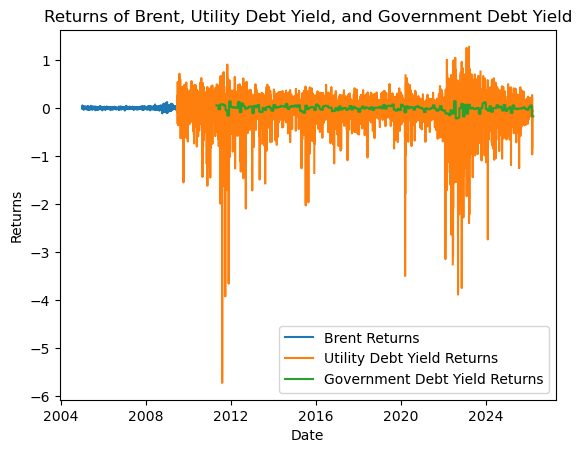

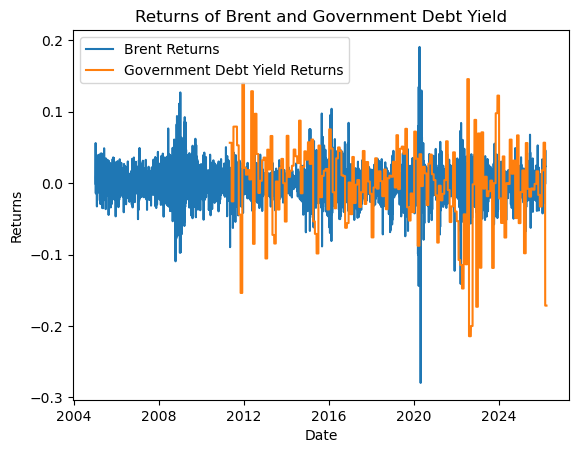

            CO1 Comdty  IGEEUA10 BVLI Index       10Y
2011-04-30   -0.002041             0.003245  0.056543
2011-05-01   -0.002045             0.003245  0.056543
2011-05-02   -0.002049             0.003245  0.056543
2011-05-03   -0.021570            -0.441611  0.056543
2011-05-04   -0.010343            -0.262664  0.056543


In [27]:
# Convert util yields to returns
# Utility duration will be higher than Govt duration 

D_util = 7.5
D_govt = 8.5

R_util = np.log1p(-D_util * util_yield_10y.diff() )
R_govt = np.log1p(-D_govt * govt_yield_10y.diff() )

R_brent = np.log1p(brent.diff() / brent.shift(1))

df = merge_dfs([R_brent, R_util, R_govt]).dropna()

plt.plot(R_brent, label='Brent Returns')
plt.plot(R_util, label='Utility Debt Yield Returns')
plt.plot(R_govt, label='Government Debt Yield Returns')
plt.legend()
plt.title('Returns of Brent, Utility Debt Yield, and Government Debt Yield')
plt.xlabel('Date')
plt.ylabel('Returns')
plt.show()

plt.plot(R_brent, label='Brent Returns')
plt.plot(R_govt, label='Government Debt Yield Returns')
plt.legend()
plt.title('Returns of Brent and Government Debt Yield')
plt.xlabel('Date')
plt.ylabel('Returns')
plt.show()

print(df.head())

# Baseline Unconditional Hedge Model

In [75]:
unconditional_model = sm.OLS(
    df['IGEEUA10 BVLI Index'], 
    sm.add_constant(
        df[['10Y','CO1 Comdty']]
        )).fit()

print(unconditional_model.summary())

                             OLS Regression Results                            
Dep. Variable:     IGEEUA10 BVLI Index   R-squared:                       0.043
Model:                             OLS   Adj. R-squared:                  0.043
Method:                  Least Squares   F-statistic:                     122.2
Date:                 Tue, 24 Mar 2026   Prob (F-statistic):           1.22e-52
Time:                         11:24:35   Log-Likelihood:                -1393.6
No. Observations:                 5402   AIC:                             2793.
Df Residuals:                     5399   BIC:                             2813.
Df Model:                            2                                         
Covariance Type:             nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0312      0.004     -7.31

# Regime Identification

In [67]:
mu_p_6m = brent.rolling(window=180).mean().dropna()
std_p_6m = brent.rolling(window=180).std().dropna()
threshold = mu_p_6m + 1.5*std_p_6m

# threshold will be shorter than brent due to rolling calculation
new_index = threshold.index
indicator=pd.Series(data=np.where(brent['CO1 Comdty'].loc[new_index] > threshold['CO1 Comdty'], 1, 0), index=new_index)

# crop indicator to fit into df
indicator = indicator[indicator.index.isin(df.index)]
df['D']=indicator
df.head()

,CO1 Comdty,IGEEUA10 BVLI Index,10Y,D
2011-04-30,-0.002041,0.003245,0.056543,1
2011-05-01,-0.002045,0.003245,0.056543,1
2011-05-02,-0.002049,0.003245,0.056543,1
2011-05-03,-0.021570,-0.441611,0.056543,0
2011-05-04,-0.010343,-0.262664,0.056543,0


# Conditional Hedge Model

In [68]:
df['govt_indic'] = df['D'] * df['10Y']
df['brent_indic'] = df['D'] * df['CO1 Comdty']

In [76]:
conditional_model = sm.OLS(
    df['IGEEUA10 BVLI Index'], 
    sm.add_constant(
        df[['10Y', 'govt_indic', 'CO1 Comdty', 'brent_indic']]
        )).fit()

print(conditional_model.summary())

                             OLS Regression Results                            
Dep. Variable:     IGEEUA10 BVLI Index   R-squared:                       0.045
Model:                             OLS   Adj. R-squared:                  0.044
Method:                  Least Squares   F-statistic:                     63.60
Date:                 Tue, 24 Mar 2026   Prob (F-statistic):           1.29e-52
Time:                         11:24:55   Log-Likelihood:                -1388.8
No. Observations:                 5402   AIC:                             2788.
Df Residuals:                     5397   BIC:                             2821.
Df Model:                            4                                         
Covariance Type:             nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const          -0.0322      0.004     -7

# Hedge Effectiveness

In [ ]:
var_R_util = R_util.var().iloc[0]
var_R_util

np.float64(0.09916234125316745)

## Unconditional Baseline

In [79]:
unconditional_res_var = unconditional_model.mse_resid
HE_uncoditional = 1- unconditional_res_var / var_R_util
HE_uncoditional

np.float64(0.01032796164959926)

## Conditional

In [80]:
conditional_res_var = conditional_model.mse_resid
HE_coditional = 1- conditional_res_var / var_R_util
HE_coditional

np.float64(0.011718334187064139)